In [0]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

appointments_data = [
    (1001, "Aarav Mehta", "Cardiology", "Apollo Hospital", "Hyderabad", "Completed", 1200),
    (1002, "Diya Sharma", "Dermatology", "Fortis Hospital", "Bangalore", "Completed", 800),
    (1003, "Rohan Verma", "Orthopedics", "AIIMS", "Delhi", "Cancelled", 1500),
    (1004, "Sneha Iyer", "Neurology", "Manipal Hospital", "Mumbai", "Completed", 2000),
    (1005, "Karan Patel", "Pediatrics", "Apollo Hospital", "Chennai", "Scheduled", 700),
    (1006, "Meera Nair", "Cardiology", "Fortis Hospital", "Hyderabad", "Completed", 1600),
    (1007, "Arjun Rao", "Dermatology", "AIIMS", "Delhi", "Completed", 900),
    (1008, "Isha Kapoor", "Orthopedics", "Manipal Hospital", "Bangalore", "Cancelled", 1400),
    (1009, "Vikram Singh", "Neurology", "Apollo Hospital", "Mumbai", "Completed", 2200),
    (1010, "Pooja Das", "Pediatrics", "Fortis Hospital", "Chennai", "Completed", 750),
    (1011, "Neha Joshi", "Cardiology", "AIIMS", "Pune", "Scheduled", 1300),
    (1012, "Rahul Khanna", "Dermatology", "Apollo Hospital", "Hyderabad", "Completed", 850)
]

columns = [
    "appointment_id",
    "patient_name",
    "department",
    "hospital",
    "city",
    "status",
    "consultation_fee"
]

df = spark.createDataFrame(appointments_data, columns)

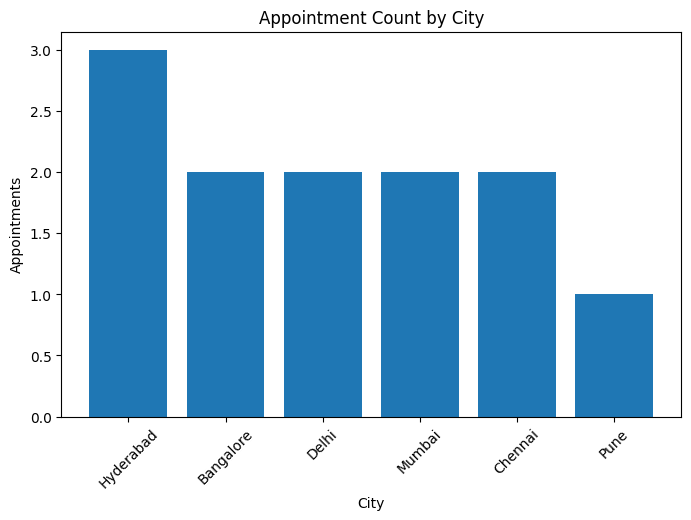

In [0]:
city_count = df.groupBy("city").count().toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(city_count["city"], city_count["count"])
plt.title("Appointment Count by City")
plt.xlabel("City")
plt.ylabel("Appointments")
plt.xticks(rotation=45)
plt.show()

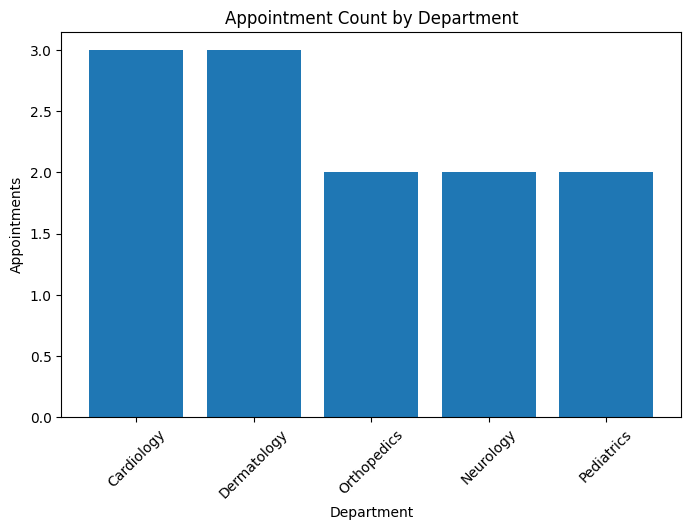

In [0]:
dept_count = df.groupBy("department").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_count["department"], dept_count["count"])
plt.title("Appointment Count by Department")
plt.xlabel("Department")
plt.ylabel("Appointments")
plt.xticks(rotation=45)
plt.show()

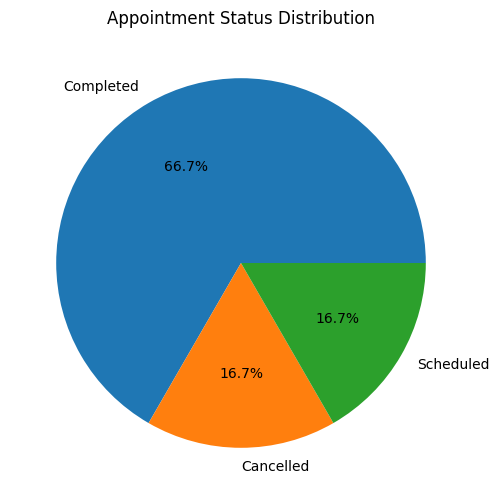

In [0]:
status_df = df.groupBy("status").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(status_df["count"], labels=status_df["status"], autopct="%1.1f%%")
plt.title("Appointment Status Distribution")
plt.show()

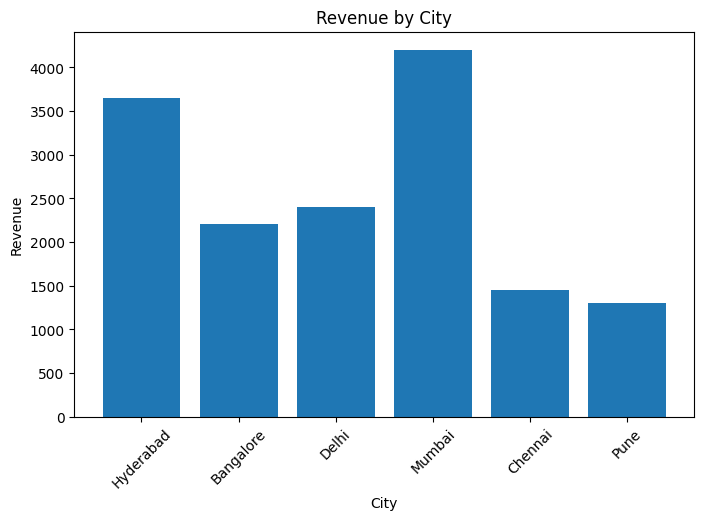

In [0]:
city_rev = df.groupBy("city").sum("consultation_fee").withColumnRenamed("sum(consultation_fee)","revenue").toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_rev["city"], city_rev["revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

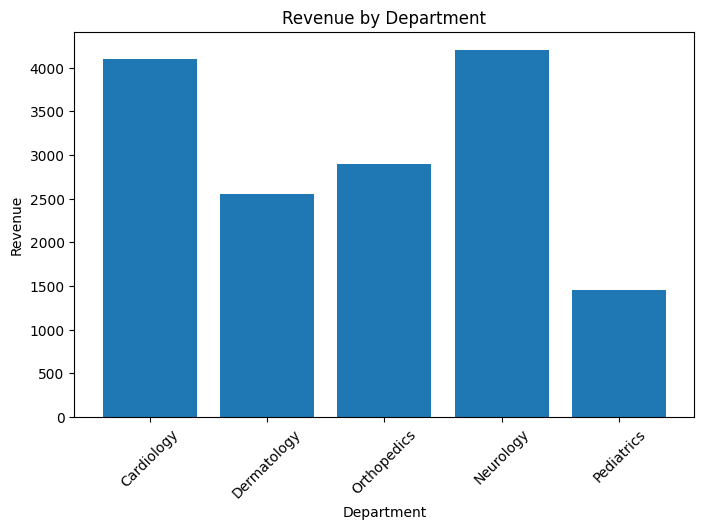

In [0]:
dept_rev = df.groupBy("department").sum("consultation_fee").withColumnRenamed("sum(consultation_fee)","revenue").toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_rev["department"], dept_rev["revenue"])
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

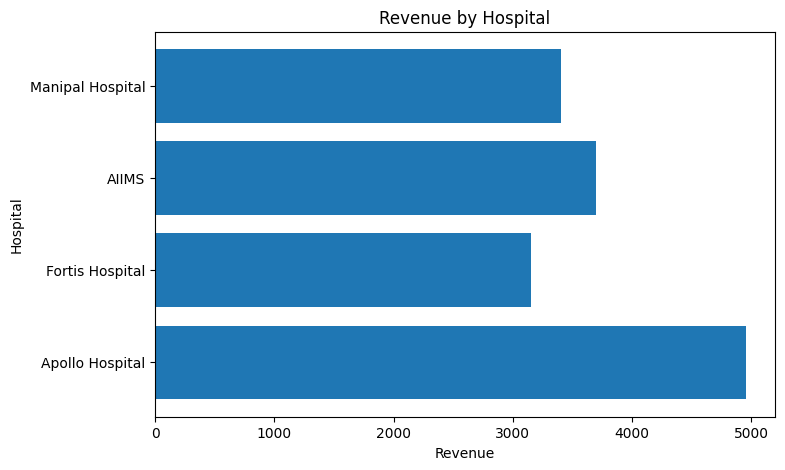

In [0]:
hospital_rev = df.groupBy("hospital").sum("consultation_fee").withColumnRenamed("sum(consultation_fee)","revenue").toPandas()

plt.figure(figsize=(8,5))
plt.barh(hospital_rev["hospital"], hospital_rev["revenue"])
plt.title("Revenue by Hospital")
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.show()

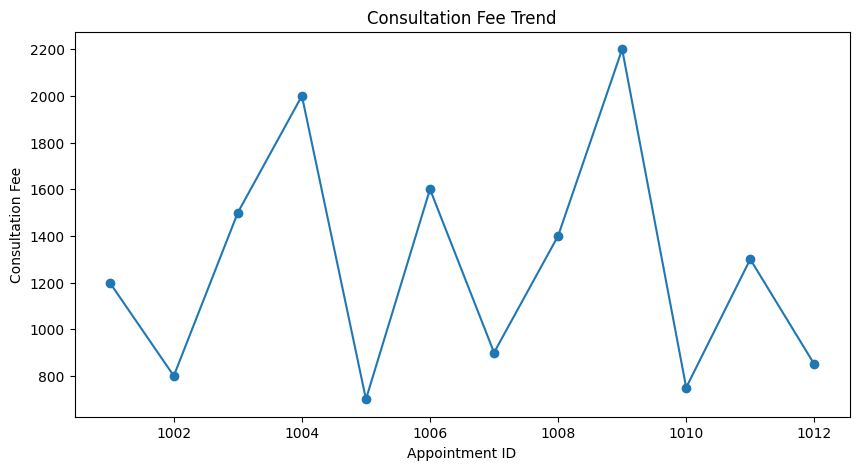

In [0]:
fee_df = df.orderBy("appointment_id").toPandas()

plt.figure(figsize=(10,5))
plt.plot(fee_df["appointment_id"], fee_df["consultation_fee"], marker="o")
plt.title("Consultation Fee Trend")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

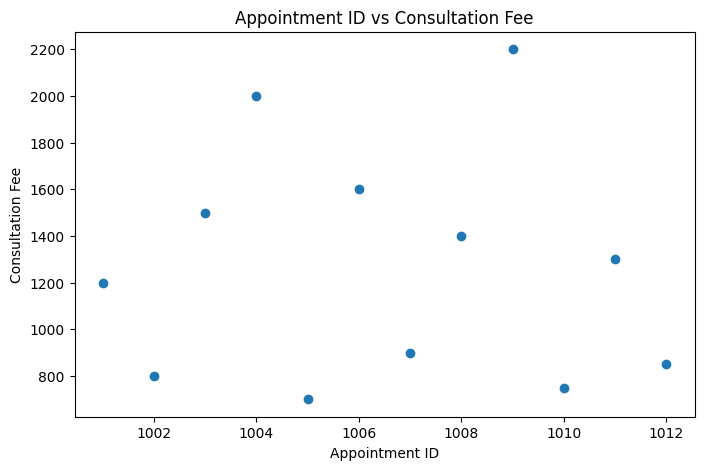

In [0]:
scatter_df = df.toPandas()

plt.figure(figsize=(8,5))
plt.scatter(scatter_df["appointment_id"], scatter_df["consultation_fee"])
plt.title("Appointment ID vs Consultation Fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

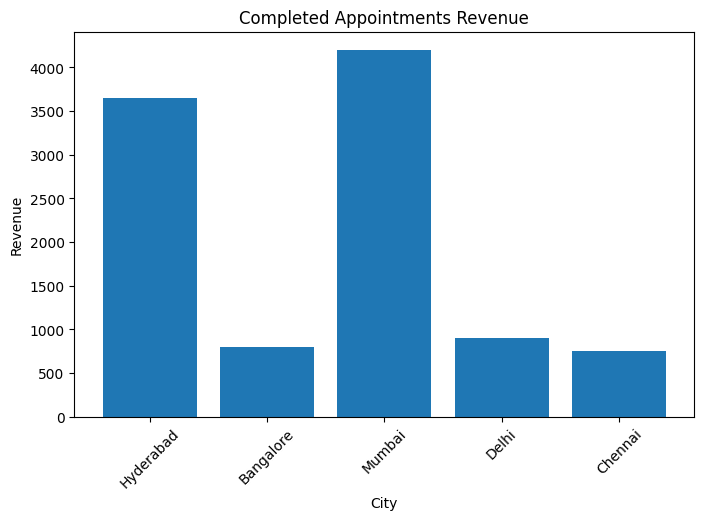

In [0]:
completed_df = df.filter(col("status")=="Completed")

completed_rev = completed_df.groupBy("city").sum("consultation_fee").withColumnRenamed("sum(consultation_fee)","revenue").toPandas()

plt.figure(figsize=(8,5))
plt.bar(completed_rev["city"], completed_rev["revenue"])
plt.title("Completed Appointments Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

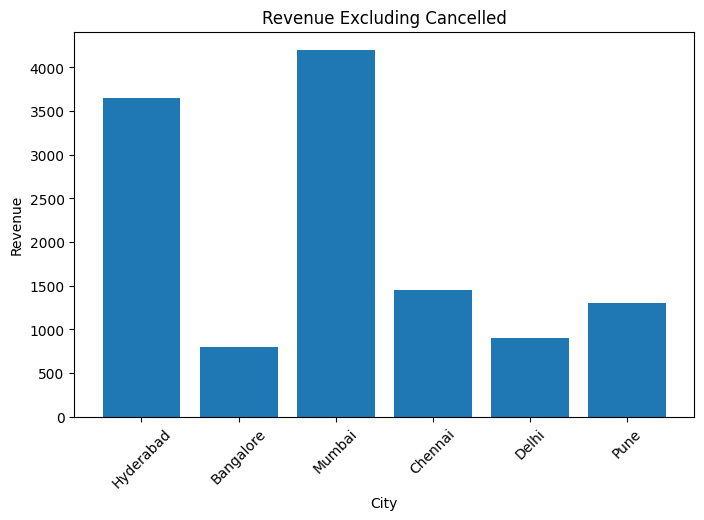

In [0]:
active_df = df.filter(col("status")!="Cancelled")

active_rev = active_df.groupBy("city").sum("consultation_fee").withColumnRenamed("sum(consultation_fee)","revenue").toPandas()

plt.figure(figsize=(8,5))
plt.bar(active_rev["city"], active_rev["revenue"])
plt.title("Revenue Excluding Cancelled")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

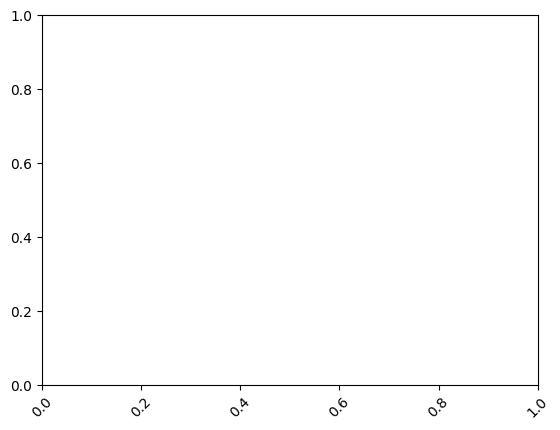

In [0]:
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Healthcare Revenue Analysis')

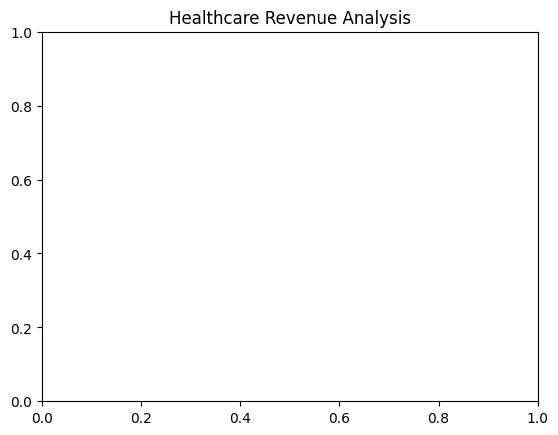

In [0]:
plt.title("Healthcare Revenue Analysis")

Text(0.5, 0, 'Hospital City')

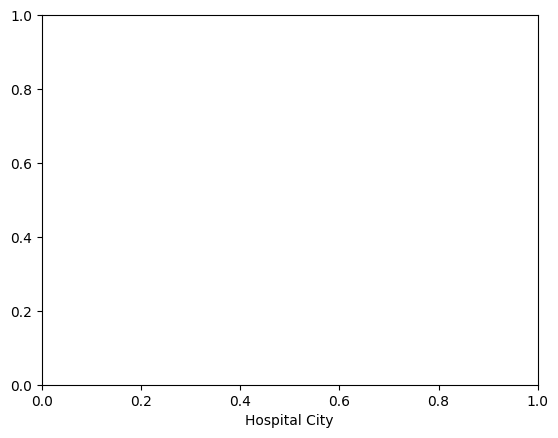

In [0]:
plt.xlabel("Hospital City")

Text(0, 0.5, 'Total Revenue')

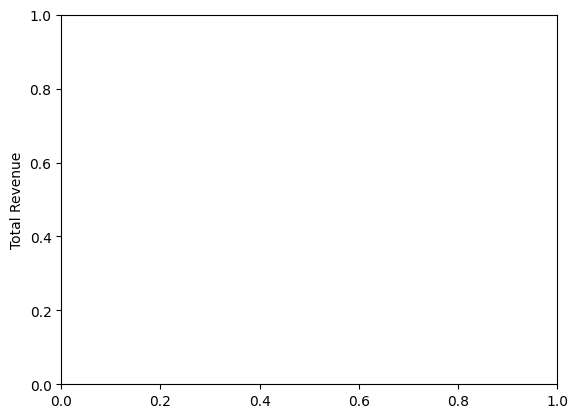

In [0]:
plt.ylabel("Total Revenue")

In [0]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [0]:
city_rev = df.groupBy("city").sum("consultation_fee").withColumnRenamed("sum(consultation_fee)","revenue")
city_rev.orderBy(col("revenue").desc()).limit(3).show()

+---------+-------+
|     city|revenue|
+---------+-------+
|   Mumbai|   4200|
|Hyderabad|   3650|
|    Delhi|   2400|
+---------+-------+



In [0]:
dept_rev = df.groupBy("department").sum("consultation_fee").withColumnRenamed("sum(consultation_fee)","revenue")
dept_rev.orderBy(col("revenue").desc()).limit(3).show()

+-----------+-------+
| department|revenue|
+-----------+-------+
|  Neurology|   4200|
| Cardiology|   4100|
|Orthopedics|   2900|
+-----------+-------+



In [0]:
hospital_rev = df.groupBy("hospital").sum("consultation_fee").withColumnRenamed("sum(consultation_fee)","revenue")
hospital_rev.orderBy("revenue").limit(1).show()

+---------------+-------+
|       hospital|revenue|
+---------------+-------+
|Fortis Hospital|   3150|
+---------------+-------+



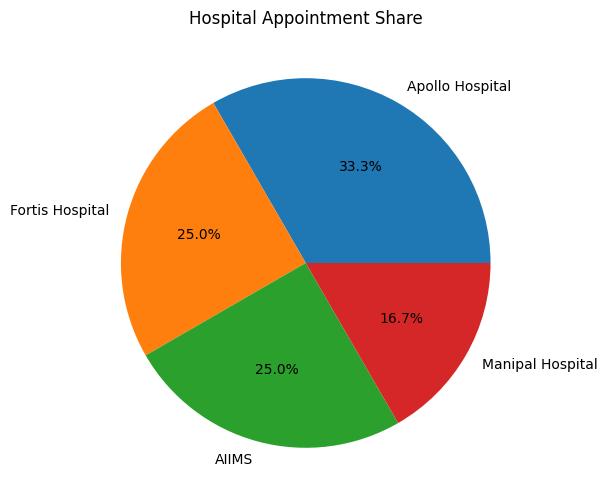

In [0]:
hospital_count = df.groupBy("hospital").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(hospital_count["count"], labels=hospital_count["hospital"], autopct="%1.1f%%")
plt.title("Hospital Appointment Share")
plt.show()

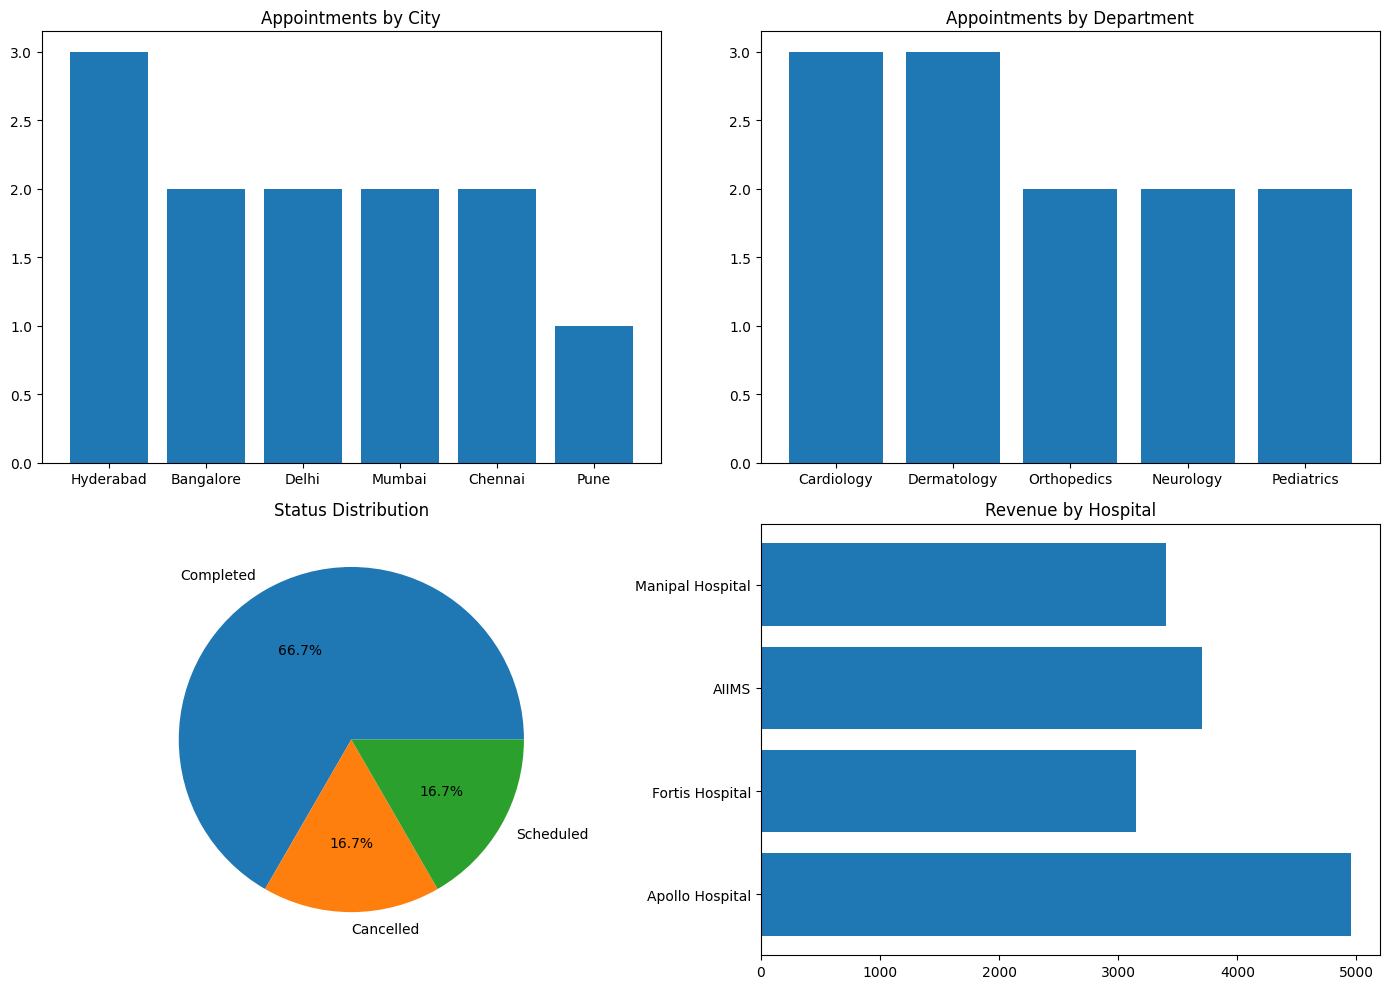

In [0]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,2,figsize=(14,10))

city_count = df.groupBy("city").count().toPandas()
axes[0,0].bar(city_count["city"], city_count["count"])
axes[0,0].set_title("Appointments by City")

dept_count = df.groupBy("department").count().toPandas()
axes[0,1].bar(dept_count["department"], dept_count["count"])
axes[0,1].set_title("Appointments by Department")

status_df = df.groupBy("status").count().toPandas()
axes[1,0].pie(status_df["count"], labels=status_df["status"], autopct="%1.1f%%")
axes[1,0].set_title("Status Distribution")

hospital_rev = df.groupBy("hospital").sum("consultation_fee").withColumnRenamed("sum(consultation_fee)","revenue").toPandas()
axes[1,1].barh(hospital_rev["hospital"], hospital_rev["revenue"])
axes[1,1].set_title("Revenue by Hospital")

plt.tight_layout()
plt.show()